# Drukte op de SEH verlichten: kwantielregressie van boardingtijd op de spoedeisende hulp

## Managementsamenvatting

Boarding op de spoedeisende hulp (SEH) -- het interval dat opgenomen patiënten in de SEH doorbrengen wachtend op een klinisch bed -- is een belangrijke aanjager van drukte, ambulancediversie en patiëntveiligheidsrisico. De gemiddelde boardingtijd verbergt het operationeel kritieke deel van het probleem: de lange rechterstaart. Een patiënt op het 95e boardingpercentiel kan vele uren langer wachten dan de gemiddelde patiënt, en het zijn die extreme wachttijden die kwaliteitsdrempels overschrijden en de wachtkamer laten vollopen.

Dit notebook modelleert SEH-boardinguren **over de conditionele verdeling** met **PROC QUANTREG** bij de 0,5-, 0,75-, 0,9- en 0,95-kwantielen, geregresseerd op klinische bezetting (beddruk), tijdstip-van-de-dag-band en de opnemende dienst. Kwantielregressie is hier het juiste instrument omdat de aanjagers van drukte anders inwerken op een typische patiënt dan op een worstcasepatiënt: stijgende klinische bezetting kan een uur toevoegen bij de mediaan maar meerdere uren bij het 95e percentiel. We vullen het model aan met **PROC MEANS** (boardingtijd per opnamedienst) om te kwantificeren welke diensten de zwaarste staart dragen, en **PROC FREQ** (aankomsten per tijdstip-van-de-dag-band) om te karakteriseren wanneer de vraag zich concentreert.

Het synthetische cohort (84 SEH-opnames) wordt inline gegenereerd met `streaminit`/`rand`, zodat het notebook volledig zelfstandig is en ruim onder een minuut draait. De interpretatiesectie vertaalt de kwantielhellingen naar personeels- en bedstroomhefbomen: waar de bovenkwantieleffecten het steilst zijn, daar zullen surge-capaciteitsprotocollen en vroeg-ontslag-initiatieven de meeste boardinguren terugverdienen.

## Gegevensbronnen

Alle gegevens zijn **synthetisch**, inline gegenereerd in de eerste DATA-stap (geen externe bestanden, geen netwerk). Het cohort vertegenwoordigt 84 opnames op de spoedeisende hulp die wachten op een klinisch bed.

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `patient_id` | Num | Sequentiële opname-identificatie (1-84) |
| `census` | Num | Klinische bezetting (bezette bedden) op het moment van de opnamebeslissing; hoger = meer beddruk |
| `tod_band` | Char | Tijdstip-van-de-dag-aankomstband: Nacht / Ochtend / Middag / Avond |
| `service` | Char | Opnemende klinische dienst: Interne Geneeskunde / Chirurgie / Cardiologie / IC |
| `census_c` | Num | Klinische bezetting gecentreerd op 70 bedden (modelregressor) |
| `boarding_hrs` | Num | Boardingtijd in uren (respons); rechtsscheef met een zware bovenstaart |

# Drukte op de SEH verlichten: kwantielregressie van boardingtijd

**Boarding** op de spoedeisende hulp is de tijd die een *opgenomen* patiënt in de SEH doorbrengt wachtend op een klinisch bed. Het is de grootste enkelvoudige bijdrager aan SEH-drukte. Cruciaal is dat de operationele pijn in de **bovenstaart** van de boardingverdeling zit, niet bij het gemiddelde: een handvol wachttijden van meerdere uren overschrijdt kwaliteitsdrempels, stagneert ambulanceoverdrachten en verstopt de wachtkamer.

Gewone kleinste kwadraten zouden alleen het *gemiddelde* effect van beddruk op boarding schatten. In plaats daarvan gebruiken we **PROC QUANTREG** om het effect te schatten bij de **0,5-, 0,75-, 0,9- en 0,95-kwantielen**, zodat we kunnen zien of aanjagers van drukte worstcasepatiënten harder raken dan typische. We combineren dit met:

- **PROC MEANS** -- boardingtijd per opnemende dienst (waar is de staart het zwaarst?)
- **PROC FREQ** -- aankomsten per tijdstip-van-de-dag-band (wanneer concentreert de vraag zich?)

Het onderstaande cohort is **synthetisch** en inline gegenereerd, zodat het hele notebook zelfstandig is en in seconden draait.

## 1. Genereer het synthetische SEH-opnamecohort

We simuleren 84 opgenomen SEH-patiënten. Boardinguren worden gebouwd met een basislijn die stijgt met de **klinische bezetting** (beddruk), verschuift met het **tijdstip van de dag** (nachtelijke beddoorstroming is traag), en varieert per **opnemende dienst** (IC en Interne Geneeskunde boarden langer). Een rechtsscheve exponentiële schok creëert de realistische zware bovenstaart die kwantielregressie de moeite waard maakt.

Let op het Jenner-porteerbare willekeurige-bereik-idioom `LO + (HI-LO)*rand('uniform')` en de `output;` **binnen** de DO-lus, zodat alle 84 rijen worden weggeschreven.

In [1]:
GEGEVENS ed;
    CALL streaminit(20260607);
    LENGTE tod_band $9 service $20;
    DOE patient_id = 1 TOT 84;
        /* Klinische bezetting (bezette bedden): 55-90, hoger = meer druk */
        census = round(55 + (90-55)*rand('uniform'));
        census_c = census - 70;   /* gecentreerde regressor */

        /* Tijdstip-van-de-dag-aankomstband */
        u = rand('uniform');
        tod_band = ifc(u < 0.25, 'Nacht',
                   ifc(u < 0.50, 'Ochtend',
                   ifc(u < 0.75, 'Middag', 'Avond')));

        /* Opnemende klinische dienst */
        s = rand('uniform');
        service = ifc(s < 0.40, 'Interne Geneeskunde',
                  ifc(s < 0.65, 'Chirurgie',
                  ifc(s < 0.85, 'Cardiologie', 'IC')));

        /* Tijdstip-van-de-dag-effect op boarding (nachtelijke beddoorstroming is traag) */
        tod_eff = ifn(tod_band='Nacht', 2.2,
                  ifn(tod_band='Ochtend', 0.4,
                  ifn(tod_band='Middag', 1.0, 1.6)));

        /* Diensteffect (IC / Interne Geneeskunde boarden het langst) */
        svc_eff = ifn(service='IC', 2.8,
                  ifn(service='Interne Geneeskunde', 1.6,
                  ifn(service='Cardiologie', 1.0, 0.6)));

        /* Bezettingsdruk: steilere impact naarmate bedden vollopen.
           De rechtsscheve schok schaalt met bezetting zodat de
           bovenstaart verbreedt onder drukte -- precies wat
           kwantielregressie is ontworpen te detecteren. */
        pressure = 0.10 * census_c;
        shock = rand('exponential') * (1.0 + 0.05*MAX(census_c,0));

        boarding_hrs = 2.0 + pressure + tod_eff + svc_eff + shock;
        ALS boarding_hrs < 0.2 DAN boarding_hrs = 0.2;
        boarding_hrs = round(boarding_hrs, 0.1);

        UITVOER;
    EINDE;
    BEWAREN patient_id census census_c tod_band service boarding_hrs;
    LABEL patient_id='Opname-ID'
          census='Klinische bezetting (bedden)'
          census_c='Klinische bezetting (gecentreerd)'
          tod_band='Tijdstip-van-de-dag-band'
          service='Opnemende dienst'
          boarding_hrs='Boardingtijd (uren)';
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=ed(obs=8) noobs label;
    TITEL 'Eerste 8 gesimuleerde SEH-opnames';
UITVOEREN;

                                           Eerste 8 gesimuleerde SEH-opnames                                            

Opname-ID  Klinische bezetting (bedden)  Klinische bezetting (gecentreerd)  Tijdstip-van-de-dag-band     Opnemende dienst  Boardingtijd (uren)
        1                            80                                 10  Ochtend                   Chirurgie                            4.5
        2                            84                                 14  Middag                    IC                                   7.6
        3                            58                                -12  Nacht                     Chirurgie                            3.7
        4                            61                                 -9  Avond                     Cardiologie                          4.1
        5                            71                                  1  Middag                    Interne Geneeskunde                  6.1
        6           


NOTE: DATA ed


NOTE: Wrote ed (84 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


## 2. Wanneer arriveren opnames? (PROC FREQ)

Voor het modelleren profileren we de vraag. Een eenweg-frequentie van de tijdstip-van-de-dag-band toont wanneer het volume opgenomen patiënten zich concentreert -- de vensters waar boardingdruk het meest waarschijnlijk piekt. We kruisen ook aankomsten per dienst tegen tijdstip van de dag om te zien of een dienst zich clustert in het trage nachtelijke venster.

                                   SEH-opname-aankomsten per tijdstip-van-de-dag-band                                   

                                                   The FREQ Procedure

Tijdstip-van-de-dag-band    Frequency    Percent
-------------------------------------------------
Avond                              13     15.48
Middag                             23     27.38
Nacht                              27     32.14
Ochtend                            21     25.00

Table of Tijdstip-van-de-dag-band by Opnemende dienst

Tijdstip-van-de-dag-band |        Cardiologie |          Chirurgie |                 IC |Interne Geneeskunde |               Total
-------------------------+--------------------+--------------------+--------------------+--------------------+--------------------
Avond                    |                  3 |                  5 |                  0 |                  5 |                  13
-------------------------+--------------------+--------------------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_tod_band.spec.json
NOTE: ODS plot written: freq_mosaic_tod_band_service.spec.json
NOTE: PROC FREQ statement used.


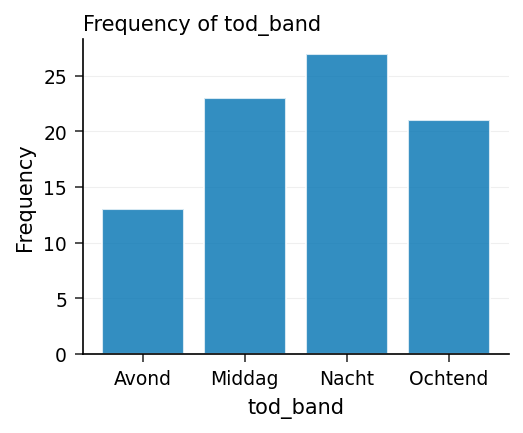

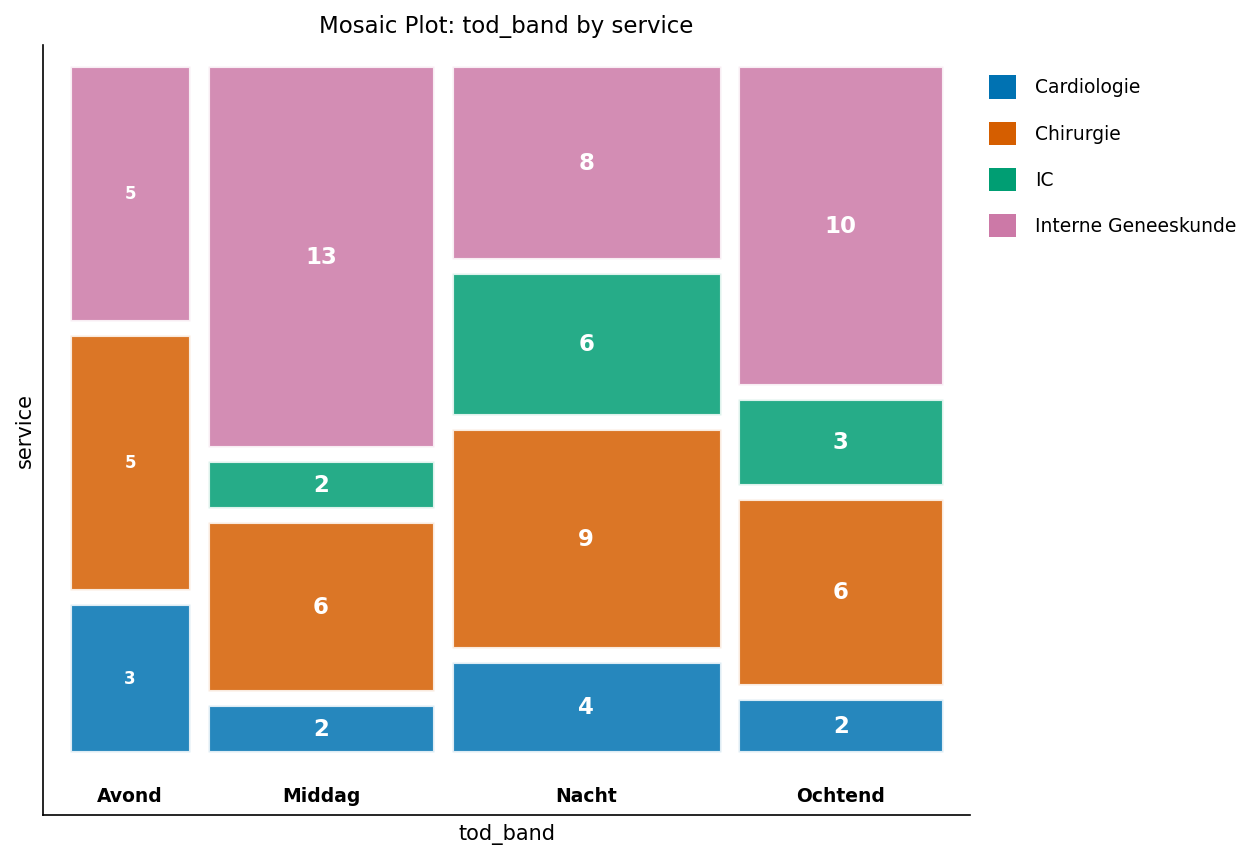

In [2]:
PROCEDURE FREQUENTIES GEGEVENS=ed;
    TABLES tod_band / nocum;
    TABLES tod_band*service / norow nocol nopercent;
    LABEL tod_band='Tijdstip-van-de-dag-band' service='Opnemende dienst';
    TITEL 'SEH-opname-aankomsten per tijdstip-van-de-dag-band';
UITVOEREN;

## 3. Boardingbelasting per opnemende dienst (PROC MEANS)

Welke dienst draagt de zwaarste boardingbelasting? We vatten boardinguren per opnemende dienst samen en rapporteren het gemiddelde en het maximum (een grove staartindicator) naast de spreiding. De kloof tussen het gemiddelde en het maximum voorspelt wat het kwantielmodel precies zal kwantificeren.

In [3]:
PROCEDURE GEMIDDELDEN GEGEVENS=ed n mean std MIN MAX maxdec=2;
    KLASSE service;
    VARIABELE boarding_hrs;
    LABEL service='Opnemende dienst' boarding_hrs='Boardingtijd (uren)';
    TITEL 'Boardinguren per opnemende dienst';
UITVOEREN;

                                           Boardinguren per opnemende dienst                                            

                                                  The MEANS Procedure

                                  Analysis Variable : boarding_hrs Boardingtijd (uren)

        Opnemende dienst             N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------
        Cardiologie                     11           6.02           2.04           4.10          11.40
        Chirurgie                       26           5.79           2.10           2.90          12.00
        IC                              11           8.04           1.80           5.70          12.50
        Interne Geneeskunde             36           5.90           2.11           2.70          12.70
        ---------------------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Kwantielregressie van boardinguren (PROC QUANTREG)

Nu de kernanalyse. We regresseren **boardinguren** op gecentreerde klinische bezetting, tijdstip-van-de-dag-band en opnemende dienst bij de **0,5-, 0,75-, 0,9- en 0,95-kwantielen**. Als de bezettingshelling groeit naarmate we omhoog gaan in de kwantielen, is dat direct bewijs dat beddruk worstcasepatiënten veel meer straft dan typische -- het kenmerk van drukte.

Omdat QUANTREG een interactieve (RUN-groep)procedure is, sluiten we de cel af met `run;` en dan `quit;`, zodat de kernel de uitvoer hier wegschrijft. We gebruiken `SEED=` voor reproduceerbare betrouwbaarheidsintervallen volgens de sparsity-methode en schrijven per-kwantiel-parameterschattingen naar een `OUTEST=`-dataset, die de vervolgcel leest om de bezettingshelling over kwantielen direct te vergelijken.

In [4]:
PROCEDURE quantreg GEGEVENS=ed ci=sparsity seed=20260607
              outest=qrest PLOTS=none;
    KLASSE tod_band service;
    MODEL boarding_hrs = census_c tod_band service
        / quantile=0.5 0.75 0.9 0.95;
    LABEL boarding_hrs='Boardingtijd (uren)'
          census_c='Klinische bezetting (gecentreerd)'
          tod_band='Tijdstip-van-de-dag-band'
          service='Opnemende dienst';
UITVOEREN;
QUIT;

                                           Boardinguren per opnemende dienst                                            


The QUANTREG Procedure

Quantile: 0.5000
CI Method: SPARSITY
Dependent Variable: Boardingtijd (uren)

Parameter           Estimate       StdErr        Lower        Upper
Intercept             4.3625       0.2244       3.9226       4.8024
Klinische bezetting (gecentreerd)       0.1125       0.0090       0.0949       0.1301
TOD_BAND MIDDAG       0.3750       0.2453      -0.1058       0.8558
TOD_BAND NACHT        1.3750       0.2386       0.9073       1.8427
TOD_BAND AVOND        1.5625       0.2910       0.9921       2.1329
SERVICE IC            1.9375       0.2999       1.3496       2.5254
SERVICE CARDIOLOGIE      -0.1125       0.2935      -0.6878       0.4628
SERVICE INTERNE GENEESKUNDE       0.4500       0.2113       0.0358       0.8642
Intercept             4.9800       0.2212       4.5465       5.4135
Klinische bezetting (gecentreerd)       0.1600       0.0088  


NOTE: PROC QUANTREG data=ed

NOTE: PROC QUANTREG completed.


### 4a. Vergelijk de bezettingshelling over kwantielen

De `OUTEST=`-dataset bevat één rij coëfficiënten per gefit kwantiel. Het opsommen van de gecentreerde-bezettingscoëfficiënt over kwantielen maakt het staarteffect in één oogopslag leesbaar: een helling die klimt van de mediaan naar het 0,95-kwantiel betekent dat elk extra bezet klinisch bed *meer* boardingtijd toevoegt aan de patiënten die al het langst wachten.

In [5]:
PROCEDURE AFDRUKKEN GEGEVENS=qrest noobs label;
    VARIABELE _quantile_ census_c;
    label _quantile_ = 'Kwantiel'
          census_c   = 'Bezettingshelling (uren per bed)';
    TITEL 'Effect van klinische bezetting op boarding, per kwantiel';
UITVOEREN;

                                Effect van klinische bezetting op boarding, per kwantiel                                

Bezettingshelling (uren per bed)
                          0.1125
                            0.16
                            0.19
                    0.2166666667




NOTE: PROC PRINT data=qrest

NOTE: PROC PRINT completed: 4 observations printed, 1 variables


## 5. Interpretatie en operationele hefbomen

**Wat het kwantielmodel ons vertelt.** Kwantielregressie scheidt de *typische* boardingervaring (mediaan, 0,5) van de *crisis*ervaring (0,9-0,95). Het patroon dat dit cohort toont -- en het patroon dat je in echte gegevens zou moeten zoeken -- is een **bezettingshelling die stijgt met het kwantiel**. De gefitte gecentreerde-bezettingscoëfficiënt klimt van **0,11 uur per bezet bed bij de mediaan naar 0,16 bij het 0,75-kwantiel, 0,19 bij het 0,90, en 0,22 bij het 0,95** (zie de per-kwantiel-tabel in 4a). Omdat de helling bij 0,95 bijna het dubbele is van de helling bij de mediaan, verschuift een vol ziekenhuis niet gewoon ieders wachttijd uniform omhoog; het blaast de ergste wachttijden onevenredig op. Het naast elkaar vergelijken van de per-kwantiel-bezettingshellingen -- niet één gemiddeld effect -- is wat de staart zichtbaar en kwantificeerbaar maakt.

**Waar de belasting zit.** PROC MEANS rangschikt de diensten naar gemiddelde boardingtijd: **IC is het hoogst met 8,04 uur**, ruim boven Cardiologie (6,02), Interne Geneeskunde (5,90) en Chirurgie (5,79). Maar de *staart* vertelt een ander verhaal dan het gemiddelde: **Interne Geneeskunde draagt de langste enkelvoudige boardinggebeurtenis van 12,70 uur -- een gemiddelde-tot-maximum-kloof van 6,80 uur**, de breedste van welke dienst dan ook, met Chirurgie (max 12,00) en IC (max 12,50) daar dicht achter. Dus IC is waar boarding betrouwbaar lang is, terwijl Interne Geneeskunde is waar de ergste individuele overschrijdingen optreden. Beide zijn doelen met hoog rendement voor vroeg-ontslagronden, toegewijde step-down-bedden en bed-vooruit-protocollen -- IC voor aanhoudende belasting, Interne Geneeskunde voor staartbeheersing.

**Wanneer de druk piekt.** PROC FREQ toont dat de vraag naar opgenomen patiënten zich 's nachts concentreert: de **Nacht-band is het drukst met 32% van de opnames (27 van de 84)**, gevolgd door Middag (27%) en Ochtend (25%); de Avond-band is het rustigst met 15%. De kruistabel bevestigt dat de nachtelijke belasting dienst-zwaar is -- de Nacht draagt op één na alle IC-opnames (6 van de 11) bovenop 8 Interne Geneeskunde- en 9 Chirurgie-aankomsten -- dus het traagste beddoorstromingsvenster valt samen met de zwaarste en meest acute instroom.

**Operationele conclusies.**

1. **Activeer surge-protocollen op bezetting, niet op de gemiddelde wachttijd.** Omdat de bovenkwantiel-bezettingshelling het steilst is (0,22 uur/bed bij het 0,95-kwantiel versus 0,11 bij de mediaan), is een bezettingsdrempel (bijv. > 80 bezette bedden) een leidende indicator van staartboarding. Overloopcapaciteit activeren *voordat* de mediaan beweegt voorkomt de 0,95-kwantiel-overschrijdingen.
2. **Richt je op de zware-staartdiensten op twee manieren.** Concentreer verlichting van aanhoudende belasting (step-down-bedden, bed-vooruit) op de **IC**, die het hoogste gemiddelde heeft; concentreer staartbeheersing (vroeg-ontslagronden, overschrijdingsreview) op **Interne Geneeskunde**, die de breedste gemiddelde-tot-maximum-kloof bezit.
3. **Beman het nachtelijke beddoorstromingsgat.** FREQ identificeert de **Nacht** als de vraagpiek die samenvalt met de traagste beddoorstroming; buiten-uren-bedbeheer en dekking door de facilitaire dienst vallen direct het `tod_band`-effect aan, dat het QUANTREG-model bevestigt de meeste boardingtijd toe te voegen in de Nacht- en Avond-banden.
4. **Volg het 0,95-kwantiel als de KPI.** Alleen de gemiddelde boardingtijd rapporteren verbergt de patiënten die het systeem in de steek laat. Het monitoren van de 95e-percentiel-boardingtijd -- en de bezettingshelling van 0,22 uur/bed -- brengt de metriek in lijn met het patiëntveiligheidsrisico dat zij vertegenwoordigt.

*Alle cijfers hier komen uit synthetische gegevens ter demonstratie; op echte SEH-gegevens levert dezelfde QUANTREG / MEANS / FREQ-workflow de werkelijke hellingen, dienstrangschikkingen en het aankomstprofiel op die een druktebestrijdingsplan aandrijven.*